# Hepatitis Dataset

In [379]:
from pycaret.datasets import get_data
ds = get_data('hepatitis')

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,0,30,2,1.0,2,2,2,2,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,0,50,1,1.0,2,1,2,2,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,0,78,1,2.0,2,1,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,0,31,1,NaN,1,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,0,34,1,2.0,2,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1


## Analysis

In [380]:
ds.shape

(154, 20)

In [381]:
ds.describe()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
count,154.000000,154.000000,154.000000,153.000000,154.000000,154.000000,154.000000,154.000000,145.000000,144.000000,150.00000,150.000000,150.000000,150.00000,149.000000,126.000000,151.00000,139.000000,88.000000,154.000000
mean,0.207792,41.246753,1.103896,1.509804,1.844156,1.350649,1.603896,1.792208,1.827586,1.583333,1.80000,1.660000,1.866667,1.88000,1.427517,105.325397,85.89404,3.817266,61.852273,1.454545
std,0.407051,12.593344,0.306121,0.501546,0.363891,0.478730,0.490682,0.407051,0.379049,0.494727,0.40134,0.475296,0.341073,0.32605,1.212149,51.508109,89.65089,0.651523,22.875244,0.499554
min,0.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,0.300000,26.000000,14.00000,2.100000,0.000000,1.000000
25%,0.000000,32.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.00000,1.000000,2.000000,2.00000,0.700000,74.250000,31.50000,3.400000,46.000000,1.000000
50%,0.000000,39.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.00000,1.000000,85.000000,58.00000,4.000000,61.000000,1.000000
75%,0.000000,50.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.00000,1.500000,132.250000,100.50000,4.200000,76.250000,2.000000
max,1.000000,78.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.00000,8.000000,295.000000,648.00000,6.400000,100.000000,2.000000


1. Class: DIE, LIVE
2. AGE: 10, 20, 30, 40, 50, 60, 70, 80
3. SEX: male, female
4. STEROID: no, yes
5. ANTIVIRALS: no, yes
6. FATIGUE: no, yes
7. MALAISE: no, yes
8. ANOREXIA: no, yes
9. LIVER BIG: no, yes
10. LIVER FIRM: no, yes
11. SPLEEN PALPABLE: no, yes
12. SPIDERS: no, yes
13. ASCITES: no, yes
14. VARICES: no, yes
15. BILIRUBIN: 0.39, 0.80, 1.20, 2.00, 3.00, 4.00
16. ALK PHOSPHATE: 33, 80, 120, 160, 200, 250
17. SGOT: 13, 100, 200, 300, 400, 500,
18. ALBUMIN: 2.1, 3.0, 3.8, 4.5, 5.0, 6.0
19. PROTIME: 10, 20, 30, 40, 50, 60, 70, 80, 90
20. HISTOLOGY: no, yes

Для цього датасету будемо вирішувати задачу класифікації для визначення 'класу' пацієнта (живий чи помер). Використаємо всі ознаки, для тренування моделі.

## Data Preparation

In [382]:
# переведемо назви усіх ознак до нижнього регістру зі зміною пробілу на "_" для зручності
ds.columns = ds.columns.str.lower().str.replace(' ', '_')
ds

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology
0,0,30,2,1.0,2,2,2,2,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,0,50,1,1.0,2,1,2,2,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,0,78,1,2.0,2,1,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,0,31,1,NaN,1,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,0,34,1,2.0,2,2,2,2,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,1,46,1,2.0,2,1,1,1,2.0,2.0,2.0,1.0,1.0,1.0,7.6,NaN,242.0,3.3,50.0,2
150,0,44,1,2.0,2,1,2,2,2.0,1.0,2.0,2.0,2.0,2.0,0.9,126.0,142.0,4.3,NaN,2
151,0,61,1,1.0,2,1,1,2,1.0,1.0,2.0,1.0,2.0,2.0,0.8,75.0,20.0,4.1,NaN,2
152,0,53,2,1.0,2,1,2,2,2.0,2.0,1.0,1.0,2.0,1.0,1.5,81.0,19.0,4.1,48.0,2


In [383]:
ds.isnull().sum()

class               0
age                 0
sex                 0
steroid             1
antivirals          0
fatigue             0
malaise             0
anorexia            0
liver_big           9
liver_firm         10
spleen_palpable     4
spiders             4
ascites             4
varices             4
bilirubin           5
alk_phosphate      28
sgot                3
albumin            15
protime            66
histology           0
dtype: int64

In [384]:
# заповнимо пропущені значення категоріальних ознак найбільш частим значенням
columns_to_fill = ["steroid", "liver_big", "liver_firm", "spleen_palpable", "spiders", "ascites", "varices"]
ds[columns_to_fill] = ds[columns_to_fill].apply(lambda x: x.fillna(x.value_counts().index[0]))

# замінимо float на int
ds[columns_to_fill] = ds[columns_to_fill].astype("int")

# замінимо (1, 2) на (0, 1)
columns_to_change = ["sex", "steroid", "antivirals", "fatigue", "malaise", "anorexia", "liver_big", "liver_firm", "spleen_palpable", "spiders", "ascites", "varices", "histology"]
for col in columns_to_change:
    ds[col].replace((1, 2), (0, 1), inplace=True)

# заповнимо пропущені значення числових ознак середнім значенням
columns_to_fill = ["bilirubin", "alk_phosphate", "sgot", "albumin", "protime"]
ds[columns_to_fill] = ds[columns_to_fill].apply(lambda x: x.fillna(x.mean()))

In [385]:
ds["class"] = ds["class"].astype("bool")

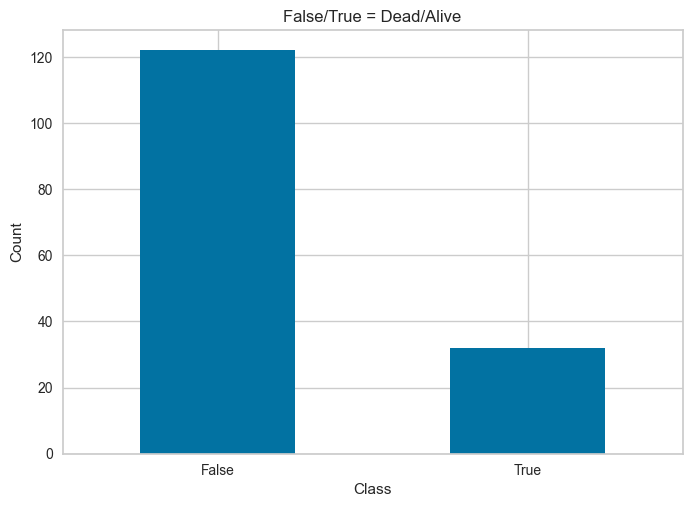

In [386]:
class_counts = ds['class'].value_counts()
plot = class_counts.plot(kind='bar', title='False/True = Dead/Alive', rot=0, xlabel='Class', ylabel='Count')

<AxesSubplot: ylabel='Frequency'>

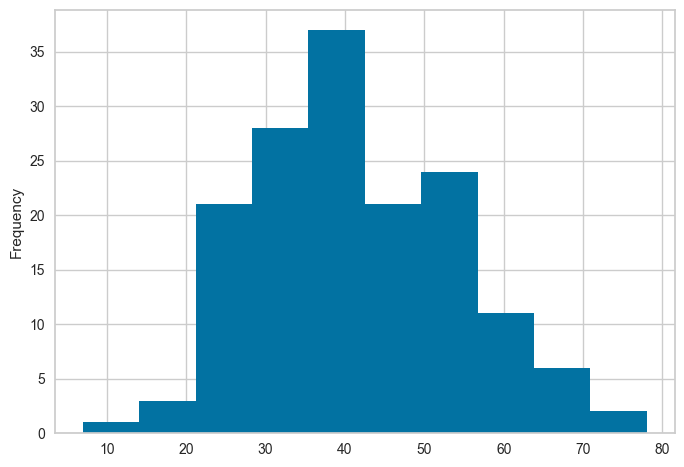

In [387]:
ds['age'].plot(kind='hist')

## Model Training

In [388]:
from pycaret import classification
categorical_features = ["sex", "steroid", "antivirals", "fatigue", "malaise", "anorexia", "liver_big", "liver_firm", "spleen_palpable", "spiders", "ascites", "varices", "histology"]
s = classification.setup(data=ds, target='class', categorical_features=categorical_features, session_id=1)

,Description,Value
0,session_id,1
1,Target,class
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(154, 20)"
5,Missing Values,False
6,Numeric Features,6
7,Categorical Features,13
8,Ordinal Features,False
9,High Cardinality Features,False


In [389]:
best_model = classification.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8682,0.9125,0.6000,0.6333,0.5800,0.5155,0.5381,0.0210
ridge,Ridge Classifier,0.8591,0.0000,0.5500,0.5000,0.5067,0.4458,0.4575,0.0020
lda,Linear Discriminant Analysis,0.8591,0.8312,0.5500,0.5000,0.5067,0.4458,0.4575,0.0030
lr,Logistic Regression,0.8509,0.8875,0.4500,0.5000,0.4667,0.4011,0.4050,0.4030
rf,Random Forest Classifier,0.8509,0.9118,0.5000,0.5333,0.4933,0.4285,0.4417,0.0260
gbc,Gradient Boosting Classifier,0.8327,0.8611,0.5000,0.4500,0.4500,0.3742,0.3908,0.0080
dt,Decision Tree Classifier,0.8318,0.7424,0.6000,0.4900,0.5105,0.4322,0.4566,0.0020
ada,Ada Boost Classifier,0.8309,0.7965,0.5500,0.6000,0.5367,0.4386,0.4622,0.0090
svm,SVM - Linear Kernel,0.8127,0.0000,0.0500,0.0500,0.0500,0.0375,0.0375,0.0020
qda,Quadratic Discriminant Analysis,0.8127,0.4962,0.0000,0.0000,0.0000,0.0000,0.0000,0.0030


In [390]:
best_model

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=1, verbose=0,
                     warm_start=False)

In [391]:
# зробимо передбачення на тестовій вибірці
predicted_class = classification.predict_model(best_model).rename({'Label': 'predicted_class'}, axis=1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.7872,0.8571,0.5000,0.6000,0.5455,0.4081,0.4110


In [392]:
predicted_class

,age,bilirubin,alk_phosphate,sgot,albumin,protime,sex_0,steroid_1,antivirals_0,fatigue_1,...,liver_big_0,liver_firm_0,spleen_palpable_1,spiders_0,ascites_0,varices_0,histology_1,class,predicted_class,Score
0,37.0,0.700000,26.000000,58.0,4.500000,100.000000,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,1.00
1,26.0,0.500000,135.000000,29.0,3.800000,60.000000,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,0.94
2,24.0,0.800000,82.000000,39.0,4.300000,61.852272,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,1.00
3,70.0,1.700000,109.000000,528.0,2.800000,35.000000,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,0.76
4,62.0,1.000000,105.325394,60.0,3.817266,61.852272,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,True,False,0.94
5,33.0,0.700000,63.000000,80.0,3.000000,31.000000,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,True,True,0.52
6,47.0,2.000000,84.000000,23.0,4.200000,66.000000,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,True,False,0.83
7,47.0,1.427517,105.325394,60.0,3.817266,61.852272,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,0.97
8,40.0,1.200000,85.000000,31.0,4.000000,100.000000,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,False,False,0.97
9,34.0,1.427517,105.325394,86.0,3.817266,61.852272,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,1.00


Результати для класифікації виживших пацієнтів є не такими точними, як того хотілося б. На це є декілька причин:
1. Мало даних у даному датасеті
2. Мала кількість виживших пацієнтів
3. Дуже велика кількість пропущених значень

In [393]:
# фіналізуємо модель
best_final = classification.finalize_model(best_model)

## Save/Load Model with Pickle

In [394]:
classification.save_model(best_model, 'hepatitis-classification-model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=['sex', 'steroid',
                                                             'antivirals',
                                                             'fatigue',
                                                             'malaise',
                                                             'anorexia',
                                                             'liver_big',
                                                             'liver_firm',
                                                             'spleen_palpable',
                                                             'spiders',
                                                             'ascites',
                                                             'varices',
                                                             'histology'],
                                       display_types=True,

In [395]:
loaded_model = classification.load_model('hepatitis-classification-model')

Transformation Pipeline and Model Successfully Loaded


In [396]:
loaded_model

Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=['sex', 'steroid',
                                                            'antivirals',
                                                            'fatigue',
                                                            'malaise',
                                                            'anorexia',
                                                            'liver_big',
                                                            'liver_firm',
                                                            'spleen_palpable',
                                                            'spiders',
                                                            'ascites',
                                                            'varices',
                                                            'histology'],
                                      display_types=True, features_todro